# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402113
- 姓名：陈曦
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-cxc106
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本报告使用 `ershoufang_list.csv` 中的福州二手房房源数据进行分析。报告先读取数据并查看字段、样本量、缺失值和重复值，然后从原始文本字段中提取面积、总价、均价、建造年份、户型和楼层等变量，再使用 `pandas` 进行分组统计、排序和透视分析，最后用 `matplotlib` 和 `seaborn` 绘制图表。通过分析可以发现：样本中晋安和仓山房源数量最多；鼓楼、台江、晋安的平均均价较高；大多数房源面积集中在 60 到 120 平方米左右；面积和总价整体呈正相关，但仍然受到地段、房龄、小区等因素影响。

## 2. 数据读取与分析目标

本次数据是福州二手房房源信息，主要字段包括市区、标题、户型、面积、方位、楼层、建造时间、小区、总价、均价和房龄等。
本报告主要分析以下几个问题：
1. 数据中一共有多少房源，字段是否完整，有没有缺失值或重复值。
2. 不同市区的房源数量、总价和均价有什么差异，造成差异的原因是什么。
3. 房屋面积、总价、均价的大致分布情况如何。
4. 房龄、楼层、户型等因素与价格是否有什么关系。

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='SimHei')

pd.set_option('display.max_columns', None)

In [114]:
# 读取数据
df = pd.read_csv('ershoufang_list.csv')
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


## 3. 数据基本情况

对数据有一个整体认识

In [115]:
# 查看数据行数和列数
df.shape

(11856, 18)

In [116]:
# 查看字段名
df.columns

Index(['id', '城市', '市区', '标题', '户型', '面积', '面积数值', '方位', '楼层', '时间', '所属小区',
       '所属区域', '房源链接', '总价', '总价数值', '均价', '均价数值', '房龄'],
      dtype='object')

In [117]:
# 查看数据类型和非空数量
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB


In [118]:
# 查看前 5 行数据
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


In [119]:
# 查看数值字段的基本统计
df.describe()

,id,面积数值,总价数值,均价数值
count,11856.00000,11856.000000,11830.000000,11830.00000
mean,5928.50000,97.888336,190.761657,19235.60093
std,3422.67673,25.924588,111.174039,6925.94972
min,1.00000,18.000000,16.800000,2169.00000
25%,2964.75000,84.730000,130.000000,15298.25000
50%,5928.50000,93.000000,173.000000,18325.50000
75%,8892.25000,113.010000,225.000000,22268.50000
max,11856.00000,500.000000,3180.000000,92968.00000


从上面的结果可以看到，数据共有 11856 条房源记录、18 个字段。数据中既有文本字段，例如 `户型`、`面积`、`楼层`、`总价`，也有已经整理好的数值字段，例如 `面积数值`、`总价数值`、`均价数值`，后面我主要从原始文本字段重新提取数值。

## 4. 数据质量检查

这一部分主要检查缺失值、重复值，以及价格和面积是否存在特别极端的情况。

In [120]:
# 每个字段的缺失值数量
df.isna().sum()

id       0
城市       0
市区       0
标题       0
户型       0
面积       0
面积数值     0
方位       0
楼层       0
时间       0
所属小区     0
所属区域     0
房源链接     0
总价      26
总价数值    26
均价      26
均价数值    26
房龄       0
dtype: int64

In [121]:
# 检查完全重复的行
df.duplicated().sum()

np.int64(0)

In [122]:
# 检查房源编号是否重复
df['id'].duplicated().sum()

np.int64(0)

In [123]:
# 查看原始文本字段的样子，方便后面做清洗
df[['面积', '总价', '均价', '时间', '楼层', '户型']].head(10)

,面积,总价,均价,时间,楼层,户型
0,103㎡,199万,19321元/㎡,2025年建造,中层(共31层),3 室 2 厅 2 卫
1,83㎡,181万,21808元/㎡,2025年建造,低层(共18层),3 室 2 厅 2 卫
2,90㎡,159万,17667元/㎡,2024年建造,高层(共33层),3 室 2 厅 1 卫
3,90㎡,300万,33334元/㎡,2025年建造,低层(共7层),3 室 2 厅 1 卫
4,107㎡,330万,30842元/㎡,2024年建造,低层(共18层),3 室 2 厅 2 卫
5,89㎡,193万,21686元/㎡,2025年建造,高层(共18层),3 室 2 厅 2 卫
6,62㎡,196万,31613元/㎡,2024年建造,低层(共16层),2 室 1 厅 1 卫
7,99㎡,299万,30203元/㎡,2024年建造,低层(共18层),3 室 2 厅 2 卫
8,75㎡,160万,21334元/㎡,2024年建造,低层(共34层),2 室 2 厅 1 卫
9,69㎡,145万,21015元/㎡,2024年建造,中层(共27层),2 室 1 厅 1 卫


In [124]:
# 查看主要数值字段中可能偏大的或偏小的记录
df[(df['面积数值'] < 20) | (df['面积数值'] > 300) | 
   (df['总价数值'] > 1000) | (df['均价数值'] > 80000)][
    ['市区', '所属小区', '户型', '面积', '总价', '均价']
].head(15)

,市区,所属小区,户型,面积,总价,均价
1960,晋安,建发朗云一区,4 室 2 厅 3 卫,204.99㎡,1460万,71223元/㎡
2316,仓山,花海里,1 室 0 厅 1 卫,18㎡,36万,20000元/㎡
2321,仓山,花海里,1 室 1 厅 1 卫,18㎡,35.1万,19500元/㎡
2360,晋安,建发朗云二区,4 室 2 厅 3 卫,180.73㎡,1150万,63631元/㎡
2379,仓山,花海里,1 室 0 厅 1 卫,18㎡,36万,20000元/㎡
2405,仓山,花海里,1 室 1 厅 1 卫,18㎡,36万,20000元/㎡
2408,晋安,建发朗云一区,5 室 2 厅 3 卫,234.49㎡,1500万,63969元/㎡
2415,晋安,建发朗云二区,4 室 2 厅 3 卫,180.73㎡,1200万,66398元/㎡
2416,晋安,建发朗云二区,4 室 2 厅 3 卫,180.73㎡,1200万,66398元/㎡
2418,晋安,建发朗云一区,5 室 2 厅 3 卫,234.49㎡,2000万,85292元/㎡


质量检查发现：`总价`、`总价数值`、`均价`、`均价数值` 各有少量缺失值；完全重复行和重复 `id` 都是 0。数据中也有少数面积很小、总价或均价很高的房源，这些可能是小户型或别墅等。因为它们不一定是录入错误，可能就是极端值，所以不直接删除这些异常值，但要在分析时注意它们对平均数的影响。

## 5. 数据清洗与字段转换

原始字段中带有 `㎡`、`万`、`元/㎡`、`年建造` 等单位含义的文字，不能直接用于计算。下面从这些文本字段中提取可以分析的数值变量。

In [125]:

data = df.copy()

# 从面积、总价、均价中去掉单位，再转成数字
data['面积_㎡'] = data['面积'].astype(str).str.replace('㎡', '', regex=False).str.strip()
data['面积_㎡'] = pd.to_numeric(data['面积_㎡'], errors='coerce')

data['总价_万元'] = data['总价'].astype(str).str.replace('万', '', regex=False).str.strip()
data['总价_万元'] = pd.to_numeric(data['总价_万元'], errors='coerce')

data['均价_元每㎡'] = data['均价'].astype(str).str.replace('元/㎡', '', regex=False).str.strip()
data['均价_元每㎡'] = pd.to_numeric(data['均价_元每㎡'], errors='coerce')

# 从时间中提取建造年份
data['建造年份'] = data['时间'].astype(str).str.extract(r'(\d{4})')[0]
data['建造年份'] = pd.to_numeric(data['建造年份'], errors='coerce')
data['房屋年龄'] = 2026 - data['建造年份']

# 从户型中提取几室、几厅、几卫
data['室'] = data['户型'].astype(str).str.extract(r'(\d+)\s*室')[0]
data['厅'] = data['户型'].astype(str).str.extract(r'(\d+)\s*厅')[0]
data['卫'] = data['户型'].astype(str).str.extract(r'(\d+)\s*卫')[0]
data['室'] = pd.to_numeric(data['室'], errors='coerce')
data['厅'] = pd.to_numeric(data['厅'], errors='coerce')
data['卫'] = pd.to_numeric(data['卫'], errors='coerce')

# 从楼层中提取低层/中层/高层，以及总楼层数
data['所在楼层'] = data['楼层'].astype(str).str.extract(r'(低层|中层|高层)')[0]
data['总楼层'] = data['楼层'].astype(str).str.extract(r'共(\d+)层')[0]
data['总楼层'] = pd.to_numeric(data['总楼层'], errors='coerce')

data[['面积', '面积_㎡', '总价', '总价_万元', '均价', '均价_元每㎡', 
      '时间', '建造年份', '户型', '室', '厅', '卫', '楼层', '所在楼层', '总楼层']].head()

,面积,面积_㎡,总价,总价_万元,均价,均价_元每㎡,时间,建造年份,户型,室,厅,卫,楼层,所在楼层,总楼层
0,103㎡,103.0,199万,199.0,19321元/㎡,19321.0,2025年建造,2025,3 室 2 厅 2 卫,3,2,2,中层(共31层),中层,31
1,83㎡,83.0,181万,181.0,21808元/㎡,21808.0,2025年建造,2025,3 室 2 厅 2 卫,3,2,2,低层(共18层),低层,18
2,90㎡,90.0,159万,159.0,17667元/㎡,17667.0,2024年建造,2024,3 室 2 厅 1 卫,3,2,1,高层(共33层),高层,33
3,90㎡,90.0,300万,300.0,33334元/㎡,33334.0,2025年建造,2025,3 室 2 厅 1 卫,3,2,1,低层(共7层),低层,7
4,107㎡,107.0,330万,330.0,30842元/㎡,30842.0,2024年建造,2024,3 室 2 厅 2 卫,3,2,2,低层(共18层),低层,18


In [126]:
# 删除总价或均价缺失的记录，其他记录保留
before_rows = len(data)
data_clean = data.dropna(subset=['面积_㎡', '总价_万元', '均价_元每㎡']).copy()
after_rows = len(data_clean)

print('清洗前数据量：', before_rows)
print('清洗后数据量：', after_rows)
print('删除记录数：', before_rows - after_rows)

清洗前数据量： 11856
清洗后数据量： 11830
删除记录数： 26


In [127]:
# 查看清洗后关键字段是否还有缺失值
data_clean[['面积_㎡', '总价_万元', '均价_元每㎡', '建造年份', '室', '厅', '卫', '所在楼层', '总楼层']].isna().sum()

面积_㎡        0
总价_万元       0
均价_元每㎡      0
建造年份        0
室           0
厅           0
卫           0
所在楼层      190
总楼层         0
dtype: int64

In [128]:
# 清洗后主要数值变量的统计
data_clean[['面积_㎡', '总价_万元', '均价_元每㎡', '房屋年龄', '室', '厅', '卫', '总楼层']].describe().round(2)

,面积_㎡,总价_万元,均价_元每㎡,房屋年龄,室,厅,卫,总楼层
count,11830.00,11830.00,11830.00,11830.00,11830.00,11830.00,11830.00,11830.00
mean,97.84,190.76,19235.60,8.02,3.00,1.88,1.68,21.14
std,25.90,111.17,6925.95,7.71,0.72,0.34,0.56,9.25
min,18.00,16.80,2169.00,0.00,1.00,0.00,0.00,1.00
25%,84.56,130.00,15298.25,2.00,3.00,2.00,1.00,15.00
50%,93.00,173.00,18325.50,5.00,3.00,2.00,2.00,21.00
75%,113.00,225.00,22268.50,10.00,3.00,2.00,2.00,28.00
max,500.00,3180.00,92968.00,41.00,8.00,3.00,11.00,106.00


本次清洗主要把面积、总价和均价中的单位去掉并转成数字，并从建造时间中提取年份，计算房屋年龄。从户型中提取室、厅、卫数量，然后从楼层中提取所在楼层类别和总楼层。价格缺失的记录不能参与价格分析，所以删除了这 26 条记录。

## 6. 描述性统计分析

下面用分组统计、排序和透视表来分析不同市区、房龄、楼层和户型的房价差异。

In [129]:
# 不同市区的房源数量、平均总价、平均均价和平均面积
city_stats = data_clean.groupby('市区').agg(
    房源数量=('id', 'count'),
    平均总价_万元=('总价_万元', 'mean'),
    中位数总价_万元=('总价_万元', 'median'),
    平均均价_元每平米=('均价_元每㎡', 'mean'),
    中位数均价_元每平米=('均价_元每㎡', 'median'),
    平均面积_平方米=('面积_㎡', 'mean')
).round(2)

city_stats.sort_values('平均均价_元每平米', ascending=False)

,房源数量,平均总价_万元,中位数总价_万元,平均均价_元每平米,中位数均价_元每平米,平均面积_平方米
市区,,,,,,
鼓楼,1239,220.88,195.0,25083.16,22973.0,88.62
台江,906,213.04,175.0,21938.26,19763.5,91.61
晋安,4346,208.58,187.0,20524.36,20000.0,98.61
仓山,3926,180.64,173.0,17979.35,17613.5,99.52
连江,176,142.88,147.5,13098.03,13445.0,108.34
马尾,169,145.87,128.0,13052.51,13072.0,109.42
长乐,106,131.09,126.0,12289.05,11736.5,105.67
福清,219,141.11,138.0,12267.33,11819.0,116.29
闽侯,630,109.33,110.0,11698.95,12844.5,92.55


从市区分组结果看，鼓楼、台江、晋安的平均均价排在前面，说明中心城区或配套较成熟区域的二手房单价更高，晋安和仓山的房源数量最多，样本量比较大，所以这两个区域对整体结果影响也比较明显。

In [130]:
# 不同房龄分类的价格情况
age_stats = data_clean.groupby('房龄').agg(
    房源数量=('id', 'count'),
    平均总价_万元=('总价_万元', 'mean'),
    平均均价_元每平米=('均价_元每㎡', 'mean'),
    中位数均价_元每平米=('均价_元每㎡', 'median')
).round(2)

age_stats.sort_values('平均均价_元每平米', ascending=False)


,房源数量,平均总价_万元,平均均价_元每平米,中位数均价_元每平米
房龄,,,,
10年以上,3055,193.41,19694.55,18667.0
2-5年,3043,188.49,19664.78,18953.0
5-10年,3049,187.51,19424.75,18477.0
2年内,2683,194.03,18011.30,15773.0


从房龄看，`10年以上`、`2-5年` 和 `5-10年` 的平均均价比较接近，`2年内` 房源的平均均价反而低一些。但不能简单理解为新房一定便宜，因为房龄和所在市区、小区位置等因素是混在一起的。

In [131]:
# 不同楼层类别的价格情况
floor_stats = data_clean.groupby('所在楼层').agg(
    房源数量=('id', 'count'),
    平均均价_元每平米=('均价_元每㎡', 'mean'),
    中位数均价_元每平米=('均价_元每㎡', 'median')
).round(2)

floor_stats

,房源数量,平均均价_元每平米,中位数均价_元每平米
所在楼层,,,
中层,3707,19369.29,18221.0
低层,3688,18935.78,18157.0
高层,4245,19251.17,18456.0


In [132]:
# 按“几室”统计面积和总价
room_stats = data_clean.groupby('室').agg(
    房源数量=('id', 'count'),
    平均面积_平方米=('面积_㎡', 'mean'),
    平均总价_万元=('总价_万元', 'mean'),
    平均均价_元每平米=('均价_元每㎡', 'mean')
).round(2)

room_stats

,房源数量,平均面积_平方米,平均总价_万元,平均均价_元每平米
室,,,,
1,303,46.05,95.15,20407.97
2,1945,70.74,136.30,19265.10
3,7183,97.36,180.35,18542.00
4,2288,125.67,269.05,20959.47
5,85,156.28,423.87,24933.65
6,19,208.46,377.21,18518.00
7,5,195.32,716.20,34234.60
8,2,410.64,2465.00,59035.00


In [133]:
# 查看均价最高的前 10 条房源
data_clean.sort_values('均价_元每㎡', ascending=False)[
    ['市区', '所属小区', '户型', '面积_㎡', '总价_万元', '均价_元每㎡', '房龄']
].head(10)

,市区,所属小区,户型,面积_㎡,总价_万元,均价_元每㎡,房龄
2446,晋安,建发朗云一区,5 室 2 厅 3 卫,234.49,2180.0,92968.0,2年内
2418,晋安,建发朗云一区,5 室 2 厅 3 卫,234.49,2000.0,85292.0,2年内
2440,晋安,建发朗云一区,5 室 2 厅 4 卫,234.49,1980.0,84439.0,2年内
2449,晋安,建发朗云一区,5 室 2 厅 4 卫,234.49,1780.0,75910.0,2年内
2448,晋安,建发朗云一区,4 室 2 厅 3 卫,204.99,1545.0,75370.0,2年内
1960,晋安,建发朗云一区,4 室 2 厅 3 卫,204.99,1460.0,71223.0,2年内
2472,晋安,建发朗云二区,4 室 2 厅 3 卫,180.73,1250.0,69164.0,2年内
2625,晋安,泰禾金府大院,5 室 3 厅 4 卫,258.63,1750.0,67665.0,2年内
2416,晋安,建发朗云二区,4 室 2 厅 3 卫,180.73,1200.0,66398.0,2年内
2415,晋安,建发朗云二区,4 室 2 厅 3 卫,180.73,1200.0,66398.0,2年内


In [134]:
# 透视表：不同市区、不同房龄的平均均价
price_pivot = pd.pivot_table(
    data_clean,
    values='均价_元每㎡',
    index='市区',
    columns='房龄',
    aggfunc='mean'
).round(0)

price_pivot

房龄,10年以上,2-5年,2年内,5-10年
市区,,,,
仓山,18435.0,18306.0,17067.0,17997.0
台江,19334.0,22428.0,23803.0,22233.0
平潭,9494.0,11866.0,11000.0,7985.0
晋安,19070.0,20841.0,20858.0,20910.0
永泰,5225.0,7186.0,7606.0,5338.0
福清,8038.0,15158.0,9215.0,14753.0
罗源,4398.0,3796.0,6435.0,4167.0
连江,9958.0,14029.0,12944.0,13799.0
长乐,9593.0,11052.0,10730.0,14448.0


从上表可以看到，同一房龄分类在不同市区的价格差异比较明显，说明区域位置对均价影响很大。

## 7. 可视化分析

下面绘制 4 张图表，分别观察房源数量、均价分布、市区均价差异，以及面积和总价之间的关系。

### 图表 1：不同市区房源数量对比

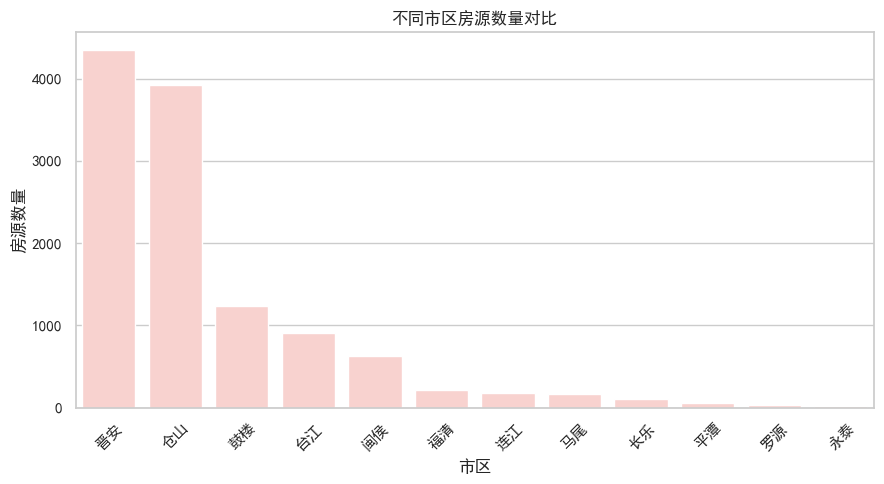

In [135]:
plt.figure(figsize=(9, 5))
district_order = data_clean['市区'].value_counts().index
sns.countplot(data=data_clean, x='市区', order=district_order, color="#FFCCC890")
plt.title('不同市区房源数量对比')
plt.xlabel('市区')
plt.ylabel('房源数量')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

图表 1 显示，晋安和仓山的房源数量明显多于其他市区，说明样本中这两个区域的房源更多。鼓楼、台江也有一定数量，但比晋安和仓山少很多。

### 图表 2：二手房均价分布

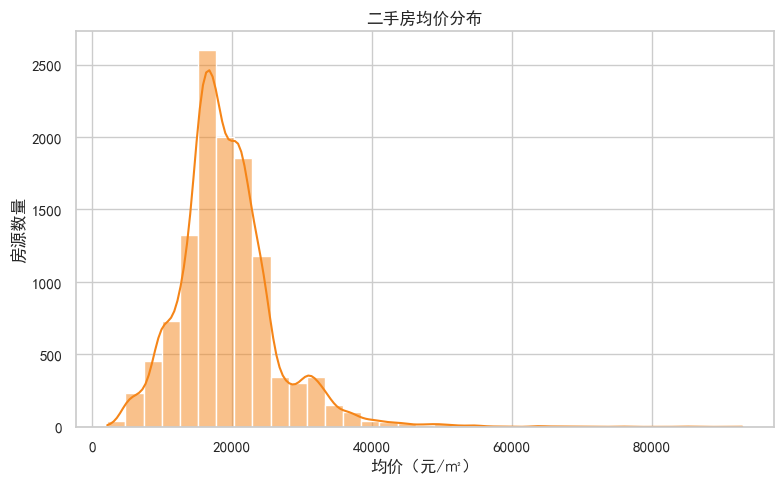

In [136]:
plt.figure(figsize=(8, 5))
sns.histplot(data_clean['均价_元每㎡'], bins=35, kde=True, color='#F58518')
plt.title('二手房均价分布')
plt.xlabel('均价（元/㎡）')
plt.ylabel('房源数量')
plt.tight_layout()
plt.show()

图表 2 显示，大多数房源的均价集中在 1.5 万到 2.3 万元/㎡左右，但右侧也有少数高价房源，说明房价分布不是完全对称的，存在一些高端房源拉高平均值。

### 图表 3：不同市区平均均价对比

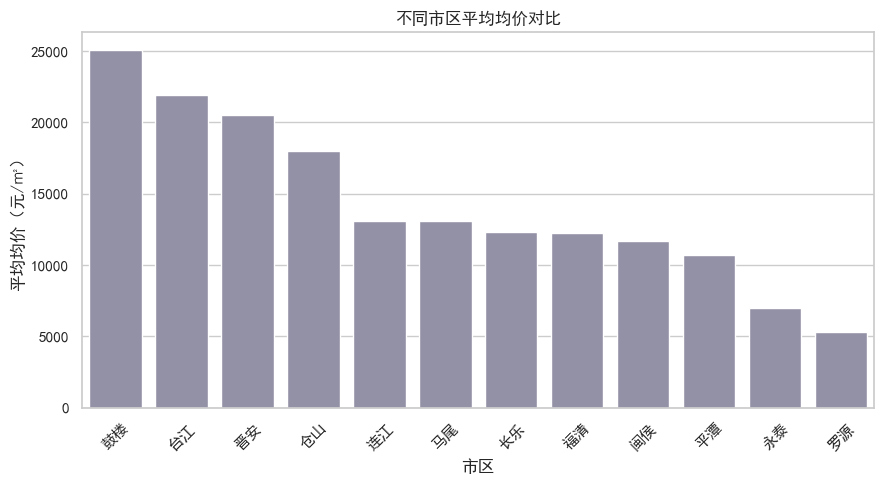

In [137]:
plt.figure(figsize=(9, 5))
city_price = city_stats.sort_values('平均均价_元每平米', ascending=False).reset_index()
sns.barplot(data=city_price, x='市区', y='平均均价_元每平米', color="#908DAA")
plt.title('不同市区平均均价对比')
plt.xlabel('市区')
plt.ylabel('平均均价（元/㎡）')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

图表 3 更直观地展示了市区之间的价格差异。鼓楼平均均价最高，台江和晋安也比较高；罗源、永泰等区域平均均价较低。这个结果和福州不同区域的区位、配套和样本结构有关。

### 图表 4：面积与总价的关系

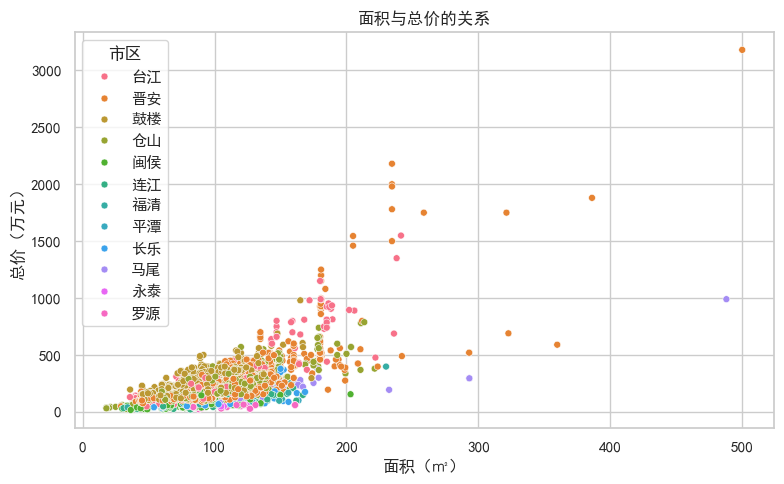

In [138]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=data_clean,
    x='面积_㎡',
    y='总价_万元',
    hue='市区',
    s=25
)
plt.title('面积与总价的关系')
plt.xlabel('面积（㎡）')
plt.ylabel('总价（万元）')
plt.legend(title='市区',  loc='upper left')
plt.tight_layout()
plt.show()

图表 4 可以看到，面积越大的房源总价一般越高，二者整体呈正相关。不过同样面积的房子总价差异也很明显，说明总价不只由面积决定，还和市区、楼盘、小区品质等因素有关。

### 补充：面积、总价、均价的相关系数

In [139]:
# 用相关系数简单衡量数值变量之间的关系
data_clean[['面积_㎡', '总价_万元', '均价_元每㎡']].corr().round(3)

,面积_㎡,总价_万元,均价_元每㎡
面积_㎡,1.000,0.643,0.143
总价_万元,0.643,1.000,0.786
均价_元每㎡,0.143,0.786,1.000


相关系数结果也支持上面的观察：面积和总价有比较明显的正相关，均价和总价也有较强关系；面积和均价的相关性较弱，说明面积大不一定单价高。

## 8. 主要结论

通过本次分析，我得到以下结论：

1. 数据共有 11856 条房源记录，清洗后用于价格分析的记录为 11830 条。价格相关字段有 26 条缺失，重复行和重复编号没有发现。
2. 房源数量最多的是晋安和仓山，说明样本中这两个区域的挂牌房源最集中。
3. 从平均均价看，鼓楼最高，其次是台江、晋安；罗源、永泰等区域均价较低，市区差异比较明显。
4. 大多数房源面积集中在中小户型，均价主要集中在 1.5 万到 2.3 万元/㎡左右，但也存在少数高价房源。
5. 面积和总价整体呈正相关，面积越大总价往往越高；但是同面积房源的价格差异仍然很大，说明区位、小区、楼层、房龄等因素也会影响价格。